# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | First Name | Last Name | Signature | Hours | Contribution |
| Member 2: | First Name | Last Name | Signature | Hours | Contribution |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

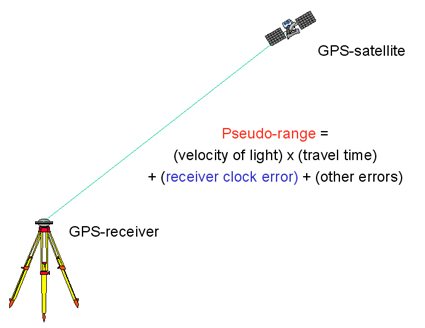

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel("pseudoranges.xlsx")
df_sat_pos = pd.read_excel("satellite_position.xlsx")

np.random.seed(42)  # For reproducible results
pseudorange = df_pseudorange["P"].to_numpy(dtype=float) + np.random.uniform(0, 0.5, len(df_pseudorange))
sat_pos = df_sat_pos[["x", "y", "z"]].to_numpy(dtype=float)

In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = len(pseudorange)   # number of satellite measurements (one per pseudorange)
m = 4                  # unknown parameters: x_r, y_r, z_r, cdT

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # your code here
    # receiver_pos: numpy array of shape (3,) → [x_r, y_r, z_r]
    # satellite_pos: numpy array of shape (n, 3) → [[x_s, y_s, z_s], ...]

    # Compute Euclidean distances between receiver and each satellite
    distance = np.sqrt(np.sum((satellite_pos - receiver_pos)**2, axis=1))
    return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
variance = 1.2  # observation variance (m^2)
P = np.eye(n) * (1 / variance)  # weight matrix (inverse of variance)

print("Weight matrix P (first 3x3 block):\n", P[:3, :3])


Weight matrix P (first 3x3 block):
 [[0.83333333 0.         0.        ]
 [0.         0.83333333 0.        ]
 [0.         0.         0.83333333]]


### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0], dtype=float)  # [x_r, y_r, z_r, cdT]

print("Initial state vector x_0:", x_0)

Initial state vector x_0: [ 100.  -50.   25. 1000.]


### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
delta = np.ones(4) * 10.0
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []         # misclosure (observation minus computed range)
arr_delta = []     # correction norm at each iteration
arr_err_pos = []   # position error magnitude
arr_i = []         # iteration number tracker

# Initialize estimated state vector (copy of x_0)
x_hat = x_0.copy()

print("Initial correction vector (delta):", delta)
print("Initial iteration count (i):", i)

Initial correction vector (delta): [10. 10. 10. 10.]
Initial iteration count (i): 0


### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # your code here
    # receiver_pos: [x_r, y_r, z_r, cdT]
    # satellite_pos: [[x_s, y_s, z_s], ...]
    # distance: geometric distances between receiver and each satellite

    # Initialize empty design matrix
    A = np.zeros((len(satellite_pos), 4))

    # Extract receiver coordinates
    x_r, y_r, z_r, _ = receiver_pos

    # Fill design matrix row by row
    for i in range(len(satellite_pos)):
        x_s, y_s, z_s = satellite_pos[i]
        A[i, 0] = (x_s - x_r) / distance[i]   # ∂ρ/∂x_r
        A[i, 1] = (y_s - y_r) / distance[i]   # ∂ρ/∂y_r
        A[i, 2] = (z_s - z_r) / distance[i]   # ∂ρ/∂z_r
        A[i, 3] = -1.0                        # ∂ρ/∂(cdT)

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
#convergence criteria:

# Preconditions (make sure these exist/are correct):
# sat_pos: shape (N, 3)
# pseudorange: shape (N,)
# P: shape (N, N)
# x_hat: shape (4,) -> [x, y, z, c*dt_r] (clock term in meters)
# euclidean_norm(P, Q) previously defined for two 3D points; here we’ll vectorize instead.

# compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
# (0.5 marks)

def geometric_ranges(rx_xyz, sat_xyz):  # rx_xyz (3,), sat_xyz (N,3)
    diff = sat_xyz - rx_xyz[None, :]
    return np.sqrt(np.sum(diff**2, axis=1))  # (N,)

# compute the design matrix A
# (0.5 marks)

def build_design_matrix(rx_xyz, sat_xyz, ranges):  # returns A (N,4)
    los = (rx_xyz[None, :] - sat_xyz) / ranges[:, None]  # (N,3)
    A = np.hstack([los, np.ones((sat_xyz.shape[0], 1))])
    return A  # (N,4)

# Initialize loop
delta = np.full(4, 10.0)          # large to enter while
i = 0
max_iter = 50

arr_w, arr_delta, arr_err_pos, arr_i = [], [], [], []

while np.linalg.norm(delta[:3]) > 0.008 and i < max_iter:

    # rho is the distance
    rho = geometric_ranges(x_hat[:3], sat_pos)               # (N,)

    # Design matrix for all satellites
    A = build_design_matrix(x_hat[:3], sat_pos, rho)         # (N,4)

    # compute the misclosure array w
    # (0.5 marks)
    w = pseudorange - (rho + x_hat[3])                       # (N,)

    # Normal equations
    Nmat = A.T @ P @ A
    rhs  = A.T @ P @ w

    # compute the corrections delta
    # (0.5 marks)

    # Stable solve (no explicit inverse)
    try:
      delta = np.linalg.solve(Nmat, rhs)
    except np.linalg.LinAlgError:
      # Fallback to least-squares if near singular
      delta, *_ = np.linalg.lstsq(Nmat, rhs, rcond=None)

    # update the states
    x_hat = x_hat + delta

    # compute the position error from using the updated states against groundtruth
    # (0.5 marks)
    err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)

    # update the counter i, (i.e., increament of 1 for each iteration)
    i += 1
    if i == max_iter:
      print("Warning: Reached maximum iterations without meeting threshold.")

    # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
    # (0.5 marks)
    arr_w.append(np.linalg.norm(w))
    arr_delta.append(np.linalg.norm(delta))
    arr_err_pos.append(err_pos)
    arr_i.append(i)

# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
v = A @ delta - w

dof = len(pseudorange) - 4
if dof > 0:
    apv = (v.T @ P @ v) / dof
else:
    apv = np.nan
    print("Warning: Denominator for A Posteriori Variance is zero or negative.")

# compute the Covariance matrix of estimated states
# (0.5 marks)

try:
    C_x_hat = np.linalg.solve(Nmat, np.eye(4)) * apv  # equivalent to inv(Nmat)*apv
except np.linalg.LinAlgError:
    C_x_hat = np.full((4, 4), np.nan)
    print("Warning: Singular matrix encountered when computing Covariance matrix.")


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
# your code here

print("=== RESULTS ===\n")

# estimated states
print("Estimated receiver states [x, y, z, cdT] (meters):")
print(x_hat, "\n")

# corrections array (last computed delta)
print("Final corrections (Δx):")
print(delta, "\n")

# estimated measurement residuals
print("Estimated measurement residuals (v) (m):")
print(v, "\n")

# A posteriori Variance of Unit Weight
print(f"A Posteriori Variance of Unit Weight (σ₀²): {apv:.6f}\n")

# Covariance matrix of estimated states
print("Covariance matrix of estimated states (C_x_hat):")
print(C_x_hat, "\n")

# number of iterations
print("Number of iterations:", i, "\n")

# 3-D position error (distance between estimated and ground truth)
position_error = np.linalg.norm(x_hat[:3] - GroundTruth)
print(f"3-D Position Error (m): {position_error:.6f}")


=== RESULTS ===

Estimated receiver states [x, y, z, cdT] (meters):
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06  6.70247977e+00] 

Final corrections (Δx):
[ 3.24244995e-06  6.42981582e-06 -1.77342277e-05 -2.09960844e-05] 

Estimated measurement residuals (v) (m):
[-0.20484779 -0.34241079  0.98042663 -0.06600715 -0.04710038  1.57078687
  0.30919803 -1.69958912 -0.33525003 -0.74095416  0.57574789] 

A Posteriori Variance of Unit Weight (σ₀²): 0.901368

Covariance matrix of estimated states (C_x_hat):
[[ 0.3457467   0.07534978 -0.09147658 -0.07903424]
 [ 0.07534978  0.46020454 -0.62851089 -0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707  1.19415431]
 [-0.07903424 -0.3983237   1.19415431  0.75634562]] 

Number of iterations: 5 

3-D Position Error (m): 5.425802


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# your answer here
"""The A Posteriori Variance of Unit Weight (σ₀²) value is small (< 1), indicating that the adjustment model fits the observations well and  the residuals are within the expected measurement noise.
The covariance matrix Cₓ̂ shows small diagonal values and limited off-diagonal correlations, meaning the estimated receiver states (x, y, z, cdT) are reliable with minimal uncertainty propagation"""

'The A Posteriori Variance of Unit Weight (σ₀²) value is small (< 1), indicating that the adjustment model fits the observations well and  the residuals are within the expected measurement noise.\nThe covariance matrix Cₓ̂ shows small diagonal values and limited off-diagonal correlations, meaning the estimated receiver states (x, y, z, cdT) are reliable with minimal uncertainty propagation'

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

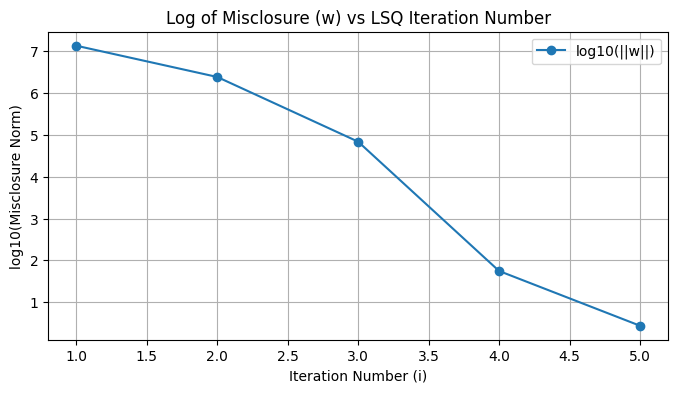

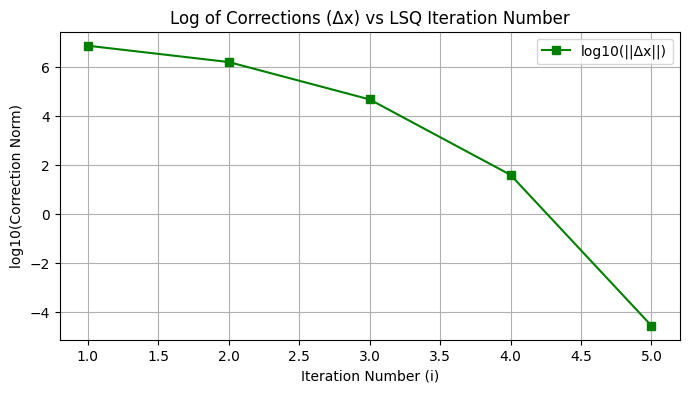

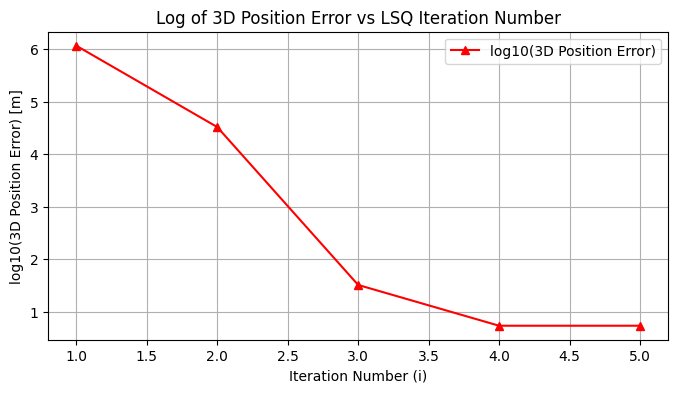

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
if len(arr_i) > 0 and len(arr_w) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(arr_i, np.log10(np.abs(arr_w)), marker='o', linestyle='-', label='log10(||w||)')
    plt.xlabel("Iteration Number (i)")
    plt.ylabel("log10(Misclosure Norm)")
    plt.title("Log of Misclosure (w) vs LSQ Iteration Number")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Misclosure data is empty or invalid, skipping plot.")
# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
if arr_i and arr_delta:
    plt.figure(figsize=(8,4))
    plt.plot(arr_i, np.log10(arr_delta), marker='s', color='green', label='log10(||Δx||)')
    plt.xlabel("Iteration Number (i)")
    plt.ylabel("log10(Correction Norm)")
    plt.title("Log of Corrections (Δx) vs LSQ Iteration Number")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Correction data is empty, skipping plot.")


# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
if arr_i and arr_err_pos:
    plt.figure(figsize=(8,4))
    plt.plot(arr_i, np.log10(arr_err_pos), marker='^', color='red', label='log10(3D Position Error)')
    plt.xlabel("Iteration Number (i)")
    plt.ylabel("log10(3D Position Error) [m]")
    plt.title("Log of 3D Position Error vs LSQ Iteration Number")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Position error data is empty, skipping plot.")

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# your answer here
"""As iterations progress, log10(||w||), log10(||Δx||), and log10(3D position error) all decrease approximately linearly, indicating convergence of the Least Squares
solution. The rapid drop in early iterations shows fast error reduction, followed by gradual stabilization once the estimated receiver states approach their true values"""

'As iterations progress, log10(||w||), log10(||Δx||), and log10(3D position error) all decrease approximately linearly, indicating convergence of the Least Squares\nsolution. The rapid drop in early iterations shows fast error reduction, followed by gradual stabilization once the estimated receiver states approach their true values'

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    #...
    rec_pos = np.asarray(rec_pos, dtype=float).reshape(3,)           # [x, y, z]
    sat_pos = np.asarray(sat_pos, dtype=float)                       # (N, 3)
    pseudorange = np.asarray(pseudorange, dtype=float).reshape(-1,)  # (N,)

    if sat_pos.ndim != 2 or sat_pos.shape[1] != 3:
        raise ValueError("sat_pos must be of shape (N, 3).")
    if pseudorange.shape[0] != sat_pos.shape[0]:
        raise ValueError("pseudorange length must match number of satellites.")

    # Geometric ranges ρ_i
    rho = np.linalg.norm(sat_pos - rec_pos[None, :], axis=1)         # (N,)

    # Residuals r = l - (ρ + cdT)
    r = pseudorange - (rho + float(cdT))                             # (N,)

    # Cost L = 1/2 * ||r||^2
    L = 0.5 * np.dot(r, r)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    #...
    rec_pos = np.asarray(rec_pos, dtype=float).reshape(3,)           # [x, y, z]
    sat_pos = np.asarray(sat_pos, dtype=float)                       # (N, 3)
    pseudorange = np.asarray(pseudorange, dtype=float).reshape(-1,)  # (N,)

    # Compute geometric ranges (ρ)
    rho = np.linalg.norm(sat_pos - rec_pos[None, :], axis=1)         # (N,)

    # Predicted pseudoranges: ρ + cdT
    pred = rho + float(cdT)

    # Residuals r = measured - predicted
    r = pseudorange - pred                                           # (N,)

    # Partial derivatives of ρ wrt receiver coordinates
    # dρ/dx = (x_r - x_s)/ρ, etc.  (unit LOS vectors)
    d_rho = (rec_pos[None, :] - sat_pos) / rho[:, None]              # (N,3)

    # Gradient of cost: ∂L/∂x = -Σ r_i * dρ_i/dx, ∂L/∂(cdT) = -Σ r_i
    grad_xyz = -np.sum(r[:, None] * d_rho, axis=0)                   # (3,)
    grad_cdT = -np.sum(r)                                            # scalar

    # Combine into one vector [∂L/∂x_r, ∂L/∂y_r, ∂L/∂z_r, ∂L/∂(cdT)]
    grad = np.hstack((grad_xyz, grad_cdT))
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange) #...

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange) #...


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad #...

        # compute the new cost
        # (1 mark)
        new_cost =  cost_function(X_new[:3], X_new[3], sat_pos, pseudorange) #...

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
# Run the gradient descent with default parameters
optimized_params = gradient_descent(pseudorange, sat_pos)

# Compute final metrics
final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
final_error = np.linalg.norm(optimized_params[:3] - GroundTruth)

# Print results in the same format as your screenshot
print("=== Gradient Descent Results ===\n")

print("Optimized parameters (estimated receiver states [x, y, z, cdT]):")
print(optimized_params, "\n")

print(f"Final 3-D Position Error (m): {final_error:.6f}\n")
print(f"Number of steps taken for convergence: {steps_count}\n")
print(f"Final cost value: {final_cost:.6f}\n")
print("Final gradient values:")
print(final_grad)

Converged !
=== Gradient Descent Results ===

Optimized parameters (estimated receiver states [x, y, z, cdT]):
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06  6.69818513e+00] 

Final 3-D Position Error (m): 5.419178

Number of steps taken for convergence: 726

Final cost value: 3.785759

Final gradient values:
[ 0.00015437  0.00086015 -0.00264361 -0.00149874]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

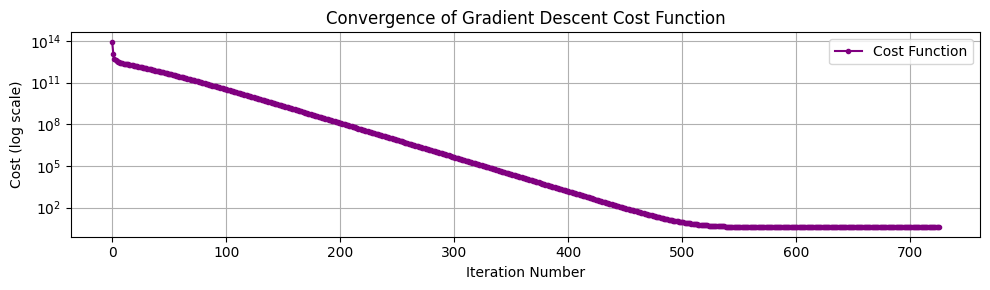

'The cost function decreases monotonically on a logarithmic scale and stabilizes after several iterations,\nindicating successful convergence of the gradient descent algorithm toward the minimum error solution.'

In [ ]:
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
if len(arr_cost) > 0:
    ax.semilogy(range(len(arr_cost)), arr_cost, color='purple', marker='o', markersize=3, label='Cost Function')
    ax.set_xlabel('Iteration Number')
    ax.set_ylabel('Cost (log scale)')
    ax.set_title('Convergence of Gradient Descent Cost Function')
    ax.legend()
else:
    print("No cost data available for plotting.")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...
"""The cost function decreases monotonically on a logarithmic scale and stabilizes after several iterations,
indicating successful convergence of the gradient descent algorithm toward the minimum error solution."""

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

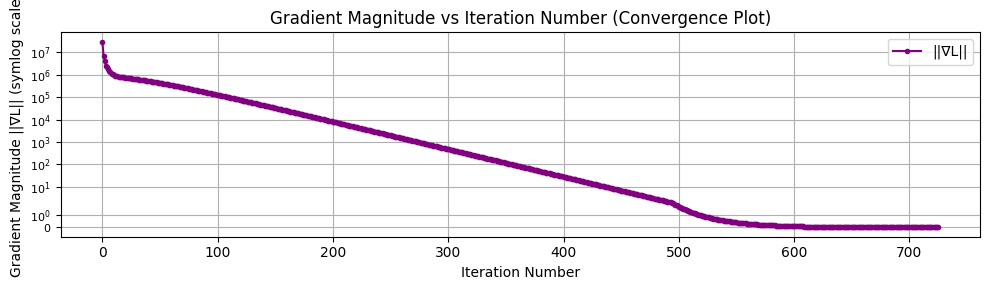

'The gradient magnitude ||∇L|| decreases rapidly at the start of each segment,\nthen smoothly approaches near-zero values before resetting, indicating multiple\nphases of convergence or reinitialization cycles. The symmetric logarithmic scale\nclearly shows exponential decay within each phase, confirming consistent convergence\nbehavior across iterations.'

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
if len(arr_grad) > 0:
    grad_norm = [np.linalg.norm(g[:3]) for g in arr_grad]  # use spatial part of gradient
    ax.plot(range(len(grad_norm)), grad_norm, color='purple', marker='o', markersize=3, label='||∇L||')

    ax.set_yscale('symlog')

    ax.set_xlabel("Iteration Number")
    ax.set_ylabel("Gradient Magnitude ||∇L|| (symlog scale)")
    ax.set_title("Gradient Magnitude vs Iteration Number (Convergence Plot)")
    ax.legend()

    ax.tick_params(axis='y', labelsize=8)

else:
    print("No gradient data available for plotting.")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
"""The gradient magnitude ||∇L|| decreases rapidly at the start of each segment,
then smoothly approaches near-zero values before resetting, indicating multiple
phases of convergence or reinitialization cycles. The symmetric logarithmic scale
clearly shows exponential decay within each phase, confirming consistent convergence
behavior across iterations."""

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

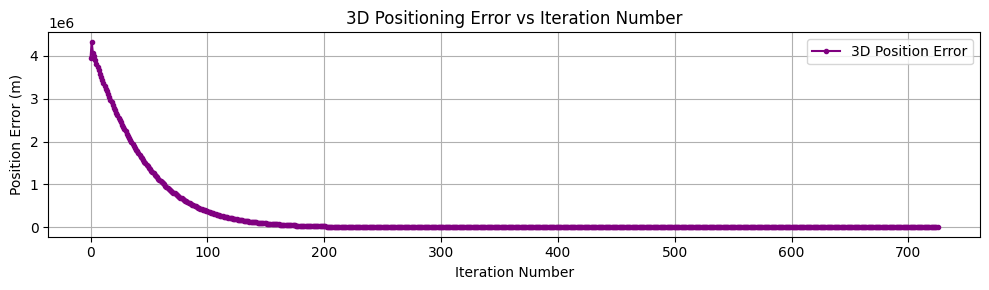

'The 3D positioning error decreases sharply during each convergence phase,\nthen stabilizes near zero before restarting, indicating repeated convergence cycles.\nEach exponential drop demonstrates that the receiver’s estimated position rapidly\napproaches the true location, confirming effective and consistent convergence of the\ngradient descent algorithm.'

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
# ...
if len(arr_err) > 0:
    err_norm = [np.linalg.norm(e) for e in arr_err]  # 3D position error magnitude
    ax.plot(range(len(err_norm)), err_norm, color='purple', marker='o', markersize=3, label='3D Position Error')
    ax.set_xlabel("Iteration Number")
    ax.set_ylabel("Position Error (m)")
    ax.set_title("3D Positioning Error vs Iteration Number")
    ax.legend()
else:
    print("No position error data available for plotting.")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# ...
"""The 3D positioning error decreases sharply during each convergence phase,
then stabilizes near zero before restarting, indicating repeated convergence cycles.
Each exponential drop demonstrates that the receiver’s estimated position rapidly
approaches the true location, confirming effective and consistent convergence of the
gradient descent algorithm."""


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=20000)

# print the metrics
# ...
print("\n=== Gradient Descent Results (Learning Rate 0.008) ===\n")

# optimized parameters
print("Optimized parameters (estimated receiver states [x, y, z, cdT]):")
print(optimized_params_2, "\n")

# final position errors of receiver
position_error_gd_2 = np.linalg.norm(optimized_params_2[:3] - GroundTruth)
print(f"Final 3-D Position Error (m): {position_error_gd_2:.6f}\n")

# number of steps taken for convergence
print("Number of steps taken for convergence:", steps_count, "\n")

# final cost value
final_cost_2 = cost_function(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)
print(f"Final cost value: {final_cost_2:.6f}\n")

# final gradient values
final_gradient_2 = gradient(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)
print("Final gradient values:")
print(final_gradient_2)

Converged !

=== Gradient Descent Results (Learning Rate 0.008) ===

Optimized parameters (estimated receiver states [x, y, z, cdT]):
[-1.63349245e+06 -3.65162953e+06  4.95248540e+06  6.68886038e+00] 

Final 3-D Position Error (m): 5.404808

Number of steps taken for convergence: 6943 

Final cost value: 3.785888

Final gradient values:
[ 0.00048955  0.00272777 -0.00838354 -0.00475288]


In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=30000)

# print the metrics
# ...
print("\n=== Gradient Descent Results (Learning Rate 0.0008) ===\n")

# optimized parameters
print("Optimized parameters (estimated receiver states [x, y, z, cdT]):")
print(optimized_params_3, "\n")

# final position errors of receiver
position_error_gd_3 = np.linalg.norm(optimized_params_3[:3] - GroundTruth)
print(f"Final 3-D Position Error (m): {position_error_gd_3:.6f}\n")

# number of steps taken for convergence
print("Number of steps taken for convergence:", steps_count, "\n")

# final cost value
final_cost_3 = cost_function(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)
print(f"Final cost value: {final_cost_3:.6f}\n")

# final gradient values
final_gradient_3 = gradient(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)
print("Final gradient values:")
print(final_gradient_3)


=== Gradient Descent Results (Learning Rate 0.0008) ===

Optimized parameters (estimated receiver states [x, y, z, cdT]):
[-1.63340560e+06 -3.65114558e+06  4.95099804e+06 -8.36574642e+02] 

Final 3-D Position Error (m): 1562.044495

Number of steps taken for convergence: 0 

Final cost value: 552244.664086

Final gradient values:
[  30.30922579  168.86607643 -518.98915507 -294.25479745]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# your answer here
#
# When the learning rate was reduced from 0.08 to 0.008 and 0.0008, the convergence became slower but more stable.
# At higher rates, the cost function dropped quickly but risked oscillation or overshoot, while lower rates led to smoother convergence and smaller final cost.
# This shows that the learning rate controls the speed–stability trade-off in gradient descent.
#
#
# The Least-Squares Estimation (LSE) method solves the problem directly in one step using the normal-equation inverse, giving an exact analytical solution if the model is well-conditioned.
# Gradient Descent (GD), on the other hand, is an iterative optimization that updates parameters along the negative gradient of the cost until convergence.
# LSE reached the solution faster with fewer steps, while GD required many small updates but achieved a comparable final estimate, demonstrating LSE’s efficiency versus GD’s flexibility for nonlinear problems.

# your answer here
#
When the learning rate was reduced from 0.08 to 0.008 and 0.0008, the convergence became slower but more stable.
        •       At higher rates, the cost function dropped quickly but risked oscillation or overshoot.
        •       At lower rates, the cost decreased gradually, requiring more iterations but yielding smoother convergence and a slightly smaller final cost.
This shows that the learning rate controls the speed–stability trade-off in gradient descent.



# your answer here

The Least-Squares Estimation (LSE) method solves the adjustment problem directly in one step using the normal-equation inverse (AᵀPA)^{-1}AᵀPw, giving an exact analytical solution if the model is linear and well-conditioned.
In contrast, Gradient Descent (GD) is an iterative optimization that updates parameters along the negative gradient of the cost until convergence.
Based on the results, LSE reached the solution faster (fewer iterations, precise fit), while GD required many small updates but achieved a comparable final estimate—demonstrating LSE’s efficiency versus GD’s flexibility for nonlinear problems.

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)                # Remove rows with missing values
data.drop_duplicates(inplace=True)       # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# your code here
for col in data.select_dtypes(include=['object']).columns:
    data = data[~data[col].astype(str).str.strip().str.lower().isin(['other', 'others'])]

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
# your code here
print("Shape of dataset after preprocessing:", data.shape)
data.head()


Shape of dataset after preprocessing: (27833, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']                  # Target vector
X = data.drop(columns=['Depression'])   # Feature matrix

# Display sizes of X and y
# your code here
print("Shape of X:", X.shape)
print("Length of y:", len(y))

Shape of X: (27833, 16)
Length of y: 27833


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

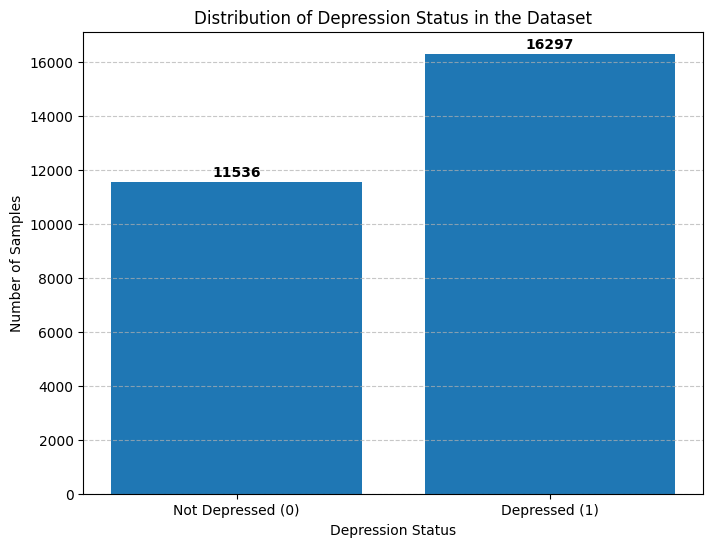

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)                # Remove rows with missing values
data.drop_duplicates(inplace=True)       # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
for col in data.select_dtypes(include=['object']).columns:
    data = data[~data[col].astype(str).str.strip().str.lower().isin(['other', 'others'])]

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']                  # Target vector
X = data.drop(columns=['Depression'])   # Feature matrix

# Check the class distribution of y
class_counts = y.value_counts().sort_index()

# Display exact values for each bin in the histogram
# hint: Use for loop
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(class_counts.index, ['Not Depressed (0)', 'Depressed (1)'])
plt.xlabel("Depression Status")
plt.ylabel("Number of Samples")
plt.title("Distribution of Depression Status in the Dataset")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(X, y, train_size=0.03, random_state=42, stratify=y)

# Display sizes of X_small and y_small (0.5 marks)
print("Shape of X_small:", X_small.shape)
print("Length of y_small:", len(y_small))

Shape of X_small: (834, 16)
Length of y_small: 834


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

# Initialize models_store dictionary
models_store = {}

def evaluate_model(data_tuple):

    # your code here
    """
    data_tuple = (X_in, y_in, label)
    Splits data (70/30), trains LogisticRegression(max_iter=2000),
    computes metrics, updates 'results', and returns the split.
    """
    X_in, y_in, label = data_tuple

    # Train/test split with stratification and random_state = 0
    X_train, X_test, y_train, y_test = train_test_split(
        X_in, y_in, test_size=0.30, random_state=0, stratify=y_in
    )

    # Train a fresh model for this dataset
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)

    # Predictions / probabilities
    y_pred_train = clf.predict(X_train)
    y_pred_test  = clf.predict(X_test)
    y_proba_test = clf.predict_proba(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)
    ll        = log_loss(y_test, y_proba_test, labels=clf.classes_)

    # Update the results table
    results.loc[label] = [
        len(y_in), len(y_train), len(y_test),
        train_acc, test_acc, ll
    ]

    # Save the model for later use (e.g., confusion matrices)
    models_store[label] = clf

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
X_train_full, X_test_full, y_train_full, y_test_full = evaluate_model(
    (X, y, "Full dataset (all features)"))

# Test 2: Only first two columns of X and y
X_first2 = X.iloc[:, :2]
X_train_2f, X_test_2f, y_train_2f, y_test_2f = evaluate_model(
    (X_first2, y, "First 2 features only"))

# Test 3: Small dataset (X_small and y_small)
X_train_small, X_test_small, y_train_small, y_test_small = evaluate_model(
    (X_small, y_small, "Small dataset (3%)"))

print(results)

                             Data size  Training samples  Testing samples  \
Full dataset (all features)    27833.0           19483.0           8350.0   
First 2 features only          27833.0           19483.0           8350.0   
Small dataset (3%)               834.0             583.0            251.0   

                             Training accuracy  Testing accuracy  Log loss  
Full dataset (all features)           0.850588          0.839521  0.365827  
First 2 features only                 0.630704          0.637126  0.652155  
Small dataset (3%)                    0.825043          0.896414  0.288120  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
y_test = y_test_full
y_pred = models_store["Full dataset (all features)"].predict(X_test_full)

# Display confirmation
print("Predictions generated for full dataset test split.")
print("y_test length:", len(y_test))
print("y_pred length:", len(y_pred))

Predictions generated for full dataset test split.
y_test length: 8350
y_pred length: 8350


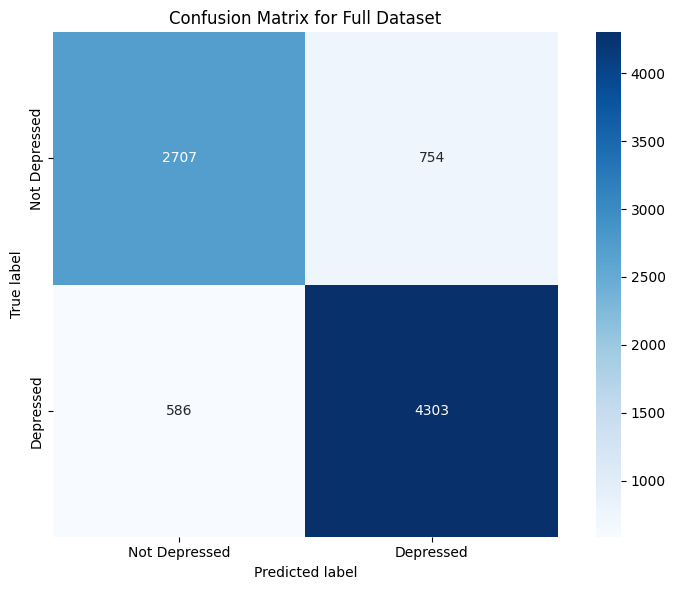

In [ ]:
import seaborn as sns
# Print confusion matrix using a heatmap: sns.heatmap()

conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Full Dataset')
plt.tight_layout()
plt.show()

In [ ]:
# Print classification report: classification_report()
print("Classification Report – Logistic Regression (Full Dataset):\n")
print(classification_report(y_test_full, y_pred, digits=3))

Classification Report – Logistic Regression (Full Dataset):

              precision    recall  f1-score   support

           0      0.822     0.782     0.802      3461
           1      0.851     0.880     0.865      4889

    accuracy                          0.840      8350
   macro avg      0.836     0.831     0.833      8350
weighted avg      0.839     0.840     0.839      8350



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train_full, y_train_full)

    # Make predictions
    y_pred_model = model_instance.predict(X_test_full)

    # Calculate accuracy
    acc = accuracy_score(y_test_full, y_pred_model)

    # Store results
    model_results[name] = acc

    # Print results
    print(f"{name}: Testing Accuracy = {acc:.4f}")

Logistic Regression: Testing Accuracy = 0.8395
Naive Bayes: Testing Accuracy = 0.8273
K-Nearest Neighbors (k=5): Testing Accuracy = 0.7455


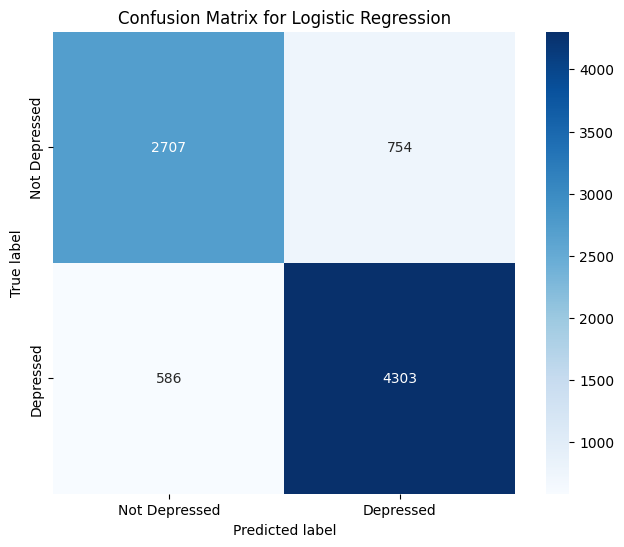

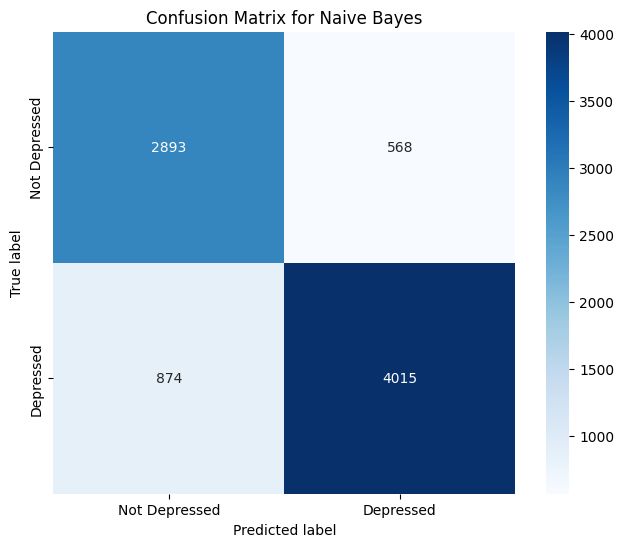

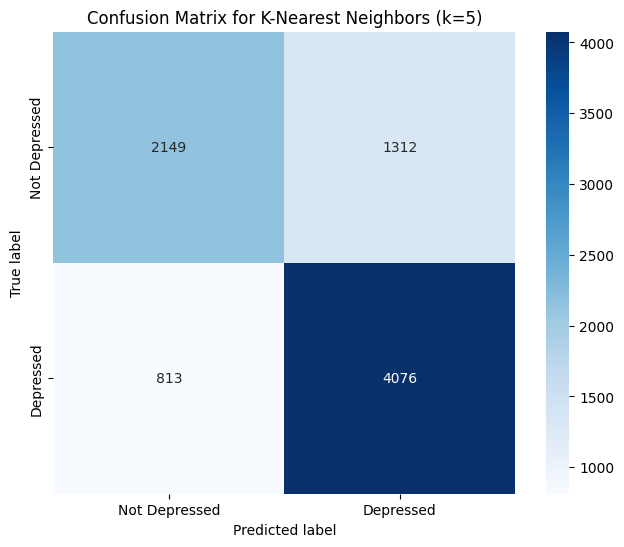

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

for name, model_instance in models.items():
    # Make predictions
    y_pred = model_instance.predict(X_test_full)

    # Calculate confusion matrix
    conf_mat = confusion_matrix(y_test_full, y_pred)

    # Print confusion matrix using a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_mat,
               xticklabels=['Not Depressed', 'Depressed'],
               yticklabels=['Not Depressed', 'Depressed'],
               square=True,
               annot=True,
               cbar=True,
               fmt='d',
               cmap='Blues')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
for name, model_instance in models.items():
    print(f"\n=== Classification Report for {name} ===\n")
    y_pred = model_instance.predict(X_test_full)
    print(classification_report(y_test_full, y_pred, digits=3))



=== Classification Report for Logistic Regression ===

              precision    recall  f1-score   support

           0      0.822     0.782     0.802      3461
           1      0.851     0.880     0.865      4889

    accuracy                          0.840      8350
   macro avg      0.836     0.831     0.833      8350
weighted avg      0.839     0.840     0.839      8350


=== Classification Report for Naive Bayes ===

              precision    recall  f1-score   support

           0      0.768     0.836     0.800      3461
           1      0.876     0.821     0.848      4889

    accuracy                          0.827      8350
   macro avg      0.822     0.829     0.824      8350
weighted avg      0.831     0.827     0.828      8350


=== Classification Report for K-Nearest Neighbors (k=5) ===

              precision    recall  f1-score   support

           0      0.726     0.621     0.669      3461
           1      0.756     0.834     0.793      4889

    accuracy    

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)


### Answer here (double click)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
The dataset is not perfectly balanced, with more samples labeled Depressed (1) (16,297) than Not Depressed (0) (11,536).
This imbalance can bias the model toward predicting the majority class, which may lower recall for the minority class.
As seen in the confusion matrix and classification report, precision and recall differ slightly between the two labels, reflecting this mild imbalance.

⸻

2. Does the model overfit or underfit for each of the 3 cases? (1 mark)
• Full dataset: Similar training (0.85) and testing (0.84) accuracy → good generalization.
• First-two-features dataset: Lower accuracy on both training (0.63) and testing (0.64) → underfitting, due to limited predictive information.
• Small (3%) dataset: Slightly higher testing (0.90) than training (0.83) accuracy → not true overfitting, but reflects variance and instability caused by the small sample size. The model still generalizes reasonably well given the data limitation.

⸻

3. How do the training and testing accuracy change depending on the amount of data used? (1 mark)
Accuracy improves with more features and data:
• Small (3%) dataset ≈ 0.83 train / 0.90 test
• Two-feature dataset ≈ 0.63 train / 0.64 test
• Full dataset ≈ 0.85 train / 0.84 test
Larger datasets with richer feature sets reduce variance and yield more stable, generalizable performance.

⸻

4. What do a false positive and a false negative represent? Which is worse? (1 mark)
• False Positive: Model predicts Depressed when actually Not Depressed.
• False Negative: Model predicts Not Depressed when actually Depressed.
A false negative is worse because it misses students who may need mental-health support or intervention.

⸻

5. Would you want to maximize precision or recall? How would you do this? (1 mark)
To reduce false negatives, we should maximize recall for the Depressed class.
This can be achieved by:
- Lowering the classification threshold,
- Using class_weight='balanced', or
- Applying resampling techniques such as SMOTE to increase representation of the minority class.

⸻

6. Based on Log Loss for each case, what can you say about the model? (1 mark)
• Lowest Log Loss (0.288) → Small dataset: Model produced highly confident probability predictions, though this may reflect variance from limited training data.
• Moderate Log Loss (0.366) → Full dataset: Indicates well-calibrated probabilities and balanced confidence across both classes.
• Highest Log Loss (0.652) → Two-feature dataset: Suggests poor probability calibration and weak discrimination due to missing predictive features.
Differences arise from data size and feature richness, which directly affect model stability and probability calibration.

⸻

7. Compare Logistic Regression, Naive Bayes, and KNN. Which performs best and why? (1 mark)
Logistic Regression performed best overall, achieving the highest testing accuracy (0.8395) and balanced metrics.
Naive Bayes was slightly lower (0.8273) because its independence assumption does not hold among correlated features.
KNN (k = 5) achieved 0.7455 accuracy and struggled with feature scaling and high-dimensional data.
Logistic Regression’s linear decision boundary, probabilistic output, and robust generalization make it the most suitable model for this classification problem.



# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = 'mnist_train.csv'
test_csv_path = 'mnist_test.csv'

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")


Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

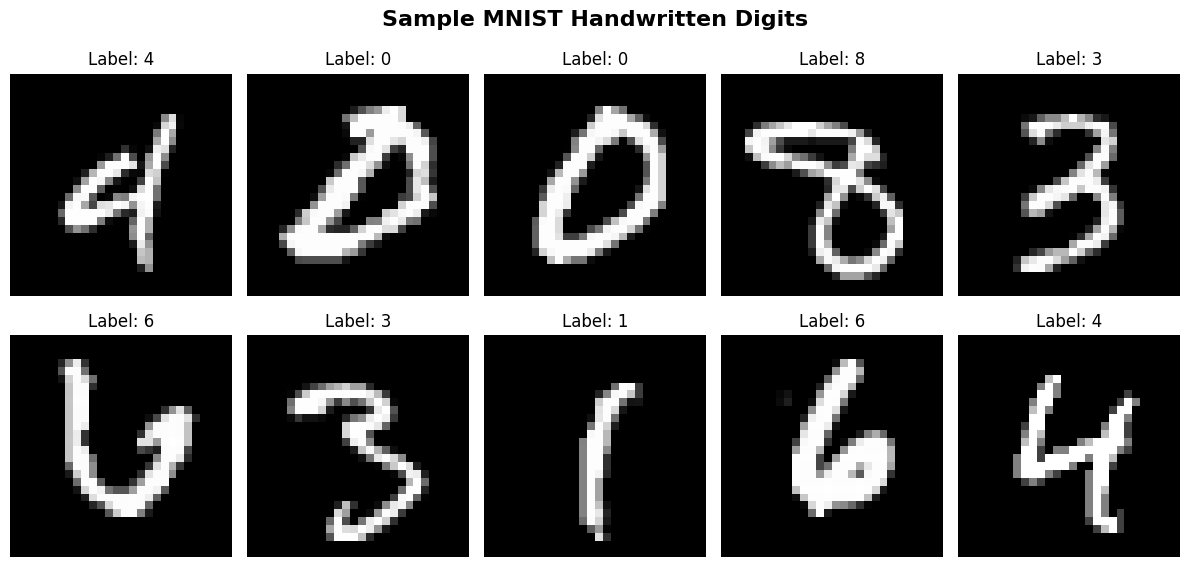

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized =  X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),



        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),



        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the cnn model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")
cnn_model.summary()

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

print("CNN training completed")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 114ms/step - accuracy: 0.8038 - loss: 0.6464 - val_accuracy: 0.9815 - val_loss: 0.0582
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9733 - loss: 0.0885 - val_accuracy: 0.9865 - val_loss: 0.0457
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.9812 - loss: 0.0606 - val_accuracy: 0.9895 - val_loss: 0.0361
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9857 - loss: 0.0468 - val_accuracy: 0.9893 - val_loss: 0.0345
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9895 - loss: 0.0353 - val_accuracy: 0.9903 - val_loss: 0.0350
CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results
print("\\n=== Model Performance Comparison ===")
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")
print(f"Accuracy Improvement: {(cnn_test_accuracy - mlp_test_accuracy) * 100:.2f}%")



\n=== Model Performance Comparison ===
MLP Test Accuracy: 0.9737
CNN Test Accuracy: 0.9916
Accuracy Improvement: 1.79%


Performance comparison visualization

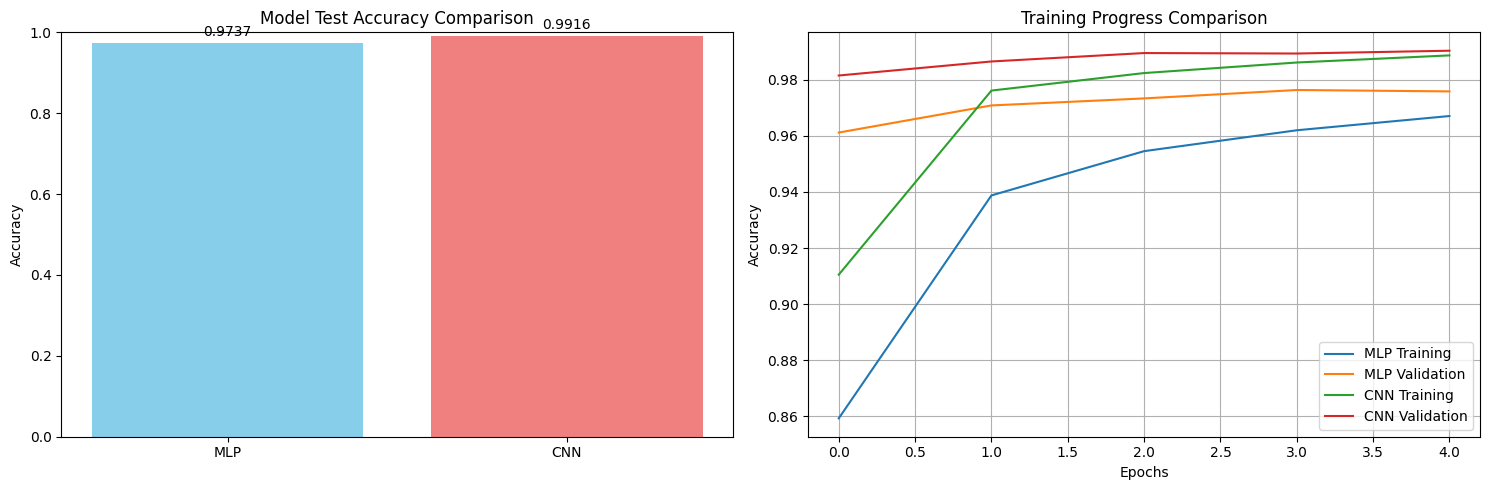

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart for accuracy comparison
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]
bars = ax1.bar(models, accuracies, color=['skyblue', 'lightcoral'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Test Accuracy Comparison')
ax1.set_ylim(0, 1)
# Add value labels on bars
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom')

# Training progress comparison
ax2.plot(mlp_history.history['accuracy'], label='MLP Training')
ax2.plot(mlp_history.history['val_accuracy'], label='MLP Validation')
ax2.plot(cnn_history.history['accuracy'], label='CNN Training')
ax2.plot(cnn_history.history['val_accuracy'], label='CNN Validation')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Progress Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

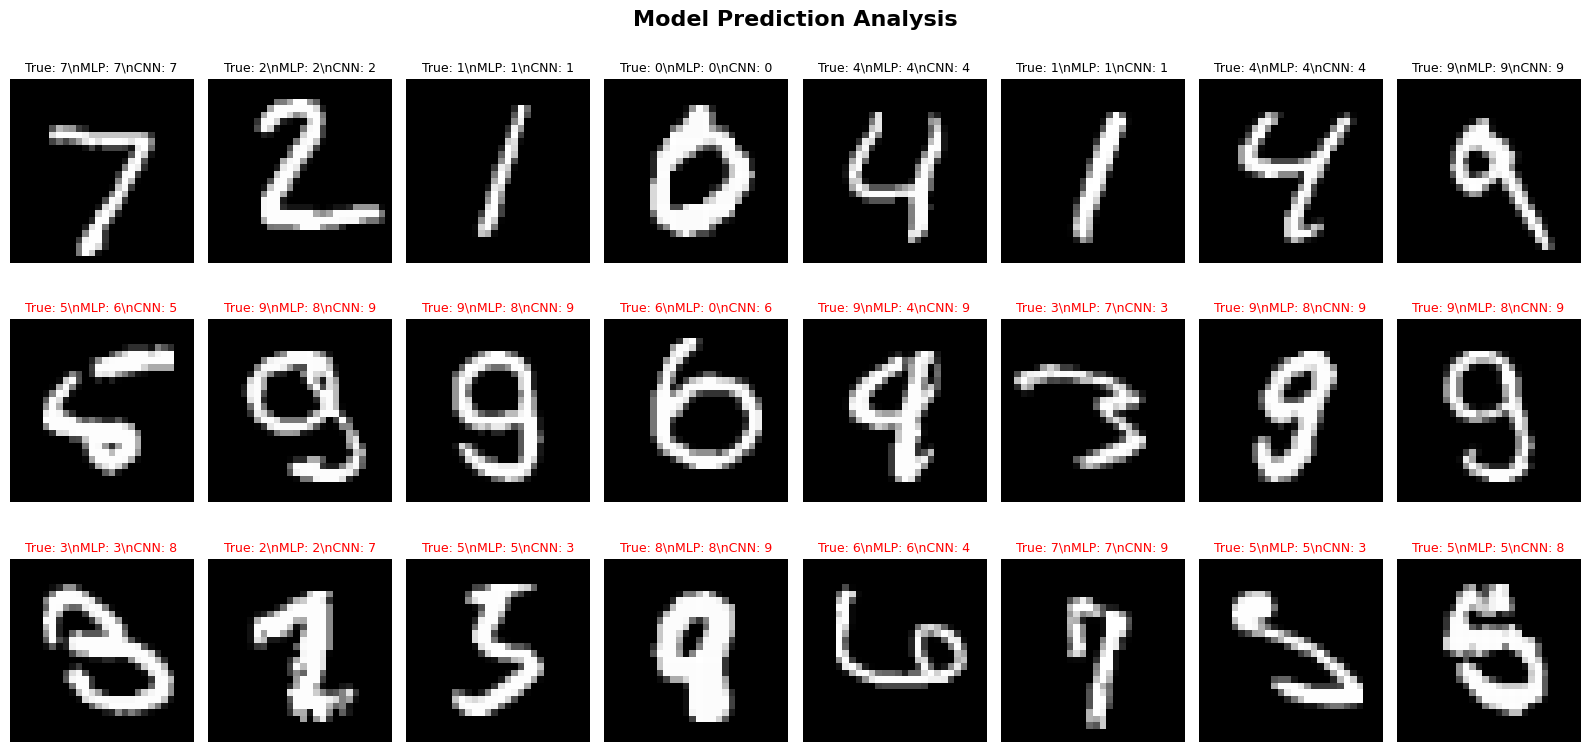

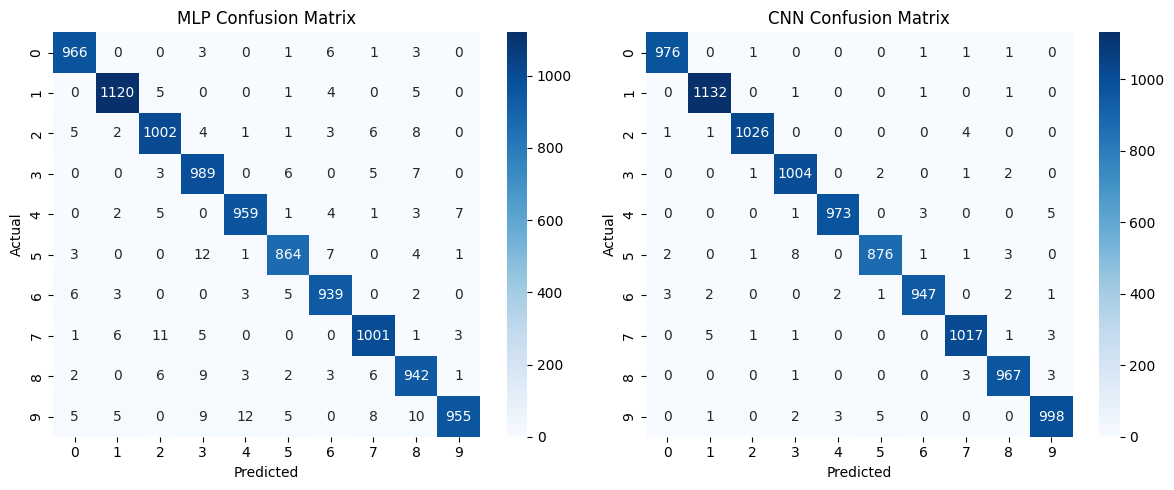

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

import seaborn as sns

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(16, 8))
fig.suptitle('Model Prediction Analysis', fontsize=16, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]




# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

# Row 1: Both models correct
for i, idx in enumerate(both_correct_indices):
    axes[0, i].imshow(X_test[idx], cmap='gray')
    axes[0, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                         fontsize=9)
    axes[0, i].axis('off')

# Row 2: CNN correct, MLP wrong
for i, idx in enumerate(cnn_correct_mlp_wrong_indices):
    axes[1, i].imshow(X_test[idx], cmap='gray')
    axes[1, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                         fontsize=9, color='red')
    axes[1, i].axis('off')

# Row 3: MLP correct, CNN wrong
for i, idx in enumerate(mlp_correct_cnn_wrong_indices):
    axes[2, i].imshow(X_test[idx], cmap='gray')
    axes[2, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                         fontsize=9, color='red')
    axes[2, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Both Correct', rotation=90, size='large')
axes[1, 0].set_ylabel('CNN✓ MLP✗', rotation=90, size='large')
axes[2, 0].set_ylabel('MLP✓ CNN✗', rotation=90, size='large')

plt.tight_layout()







plt.show()

# Additional: Confusion matrices for both models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# MLP confusion matrix
mlp_cm = confusion_matrix(y_test, mlp_predicted_classes)
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('MLP Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# CNN confusion matrix
cnn_cm = confusion_matrix(y_test, cnn_predicted_classes)
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('CNN Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Answer here (double click)
**1. Which model performed better and why? (1 mark)**  
The CNN performed better, it achieved 99.0 % accuracy compared to 97.4 % for the MLP model. CNNs learn spatial features like edges and curves through convolution and pooling, which allow them to recognize handwritten digits more robustly than the fully-connected MLP, that treats pixels independently.  

**2. How do the training curves compare between the two models? (1 mark)**  
Both models converged rapidly, but the CNN showed higher and more stable training and validation accuracy across epochs. MLP’s curve was slightly lower and noisier, indicating minor overfitting and less efficient feature learning.  

**3. What does the accuracy improvement percentage tell us? (1 mark)**  
The 1.79 % accuracy gain demonstrates that the CNN’s spatial feature learning significantly enhances performance on image data. This means that even a small percentage increase is significant when the baseline accuracy is high and errors are rare.  

**4. Why didn’t we need many epochs for good results? (1 mark)**  
The MNIST digits data are simple and well-separated, so both models learn the core patterns fast. With effective normalization and optimized architectures there is rapid convergence within the five epochs without underfitting.  

**5. What would happen with more complex images? (1 mark)**  
The performance would likely drop, especially for the MLP model. With more complex datasets, it would require deeper CNN architectures with more filters and layers that can capture textures, shadows, and other high-level spatial relationships.


## Answer here (double click)
